In [1]:
import tarfile
import urllib

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns
from mlxtend.plotting import plot_decision_regions

import pandas as pd

from sklearn.decomposition import PCA
from sklearn.metrics import f1_score, confusion_matrix, r2_score, mean_squared_error, classification_report, mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

import statistics

# Configuración matplotlib
# ==============================================================================
plt.rcParams['image.cmap'] = "bwr"
#plt.rcParams['figure.dpi'] = "100"
plt.rcParams['savefig.bbox'] = "tight"
style.use('ggplot') or plt.style.use('ggplot')

# Configuración warnings
# ==============================================================================
import warnings
warnings.filterwarnings('ignore')

**1.-Lea la descripción de las columnas del dataset que está disponible en el enlace.
La variable objetivo es MEDV.**

In [2]:
data=pd.read_csv('boston.csv') #una varibale con una base de datos asignada (funcion de read_csv)
data.head(10)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
5,0.02985,0.0,2.18,0,0.458,6.430,58.7,6.0622,3,222,18.7,394.12,5.21,28.7
6,0.08829,12.5,7.87,0,0.524,6.012,66.6,5.5605,5,311,15.2,395.60,12.43,22.9
7,0.14455,12.5,7.87,0,0.524,6.172,96.1,5.9505,5,311,15.2,396.90,19.15,27.1
8,0.21124,12.5,7.87,0,0.524,5.631,100.0,6.0821,5,311,15.2,386.63,29.93,16.5
9,0.17004,12.5,7.87,0,0.524,6.004,85.9,6.5921,5,311,15.2,386.71,17.10,18.9


**3. Muestre las dimensiones del dataframe y el tipo de las columnas (predictores).**

In [3]:
data.size

7084

**4. Muestre los valores estadísticos básicos de todas las columnas (contador, media,
desviación estándar, valor mínimo, valor máximo y los cuartiles).**

In [4]:
data.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


**5. Genere los gráficos por pares de todas las columnas con el siguiente comando:
sns.pairplot (datos)**

CRIM


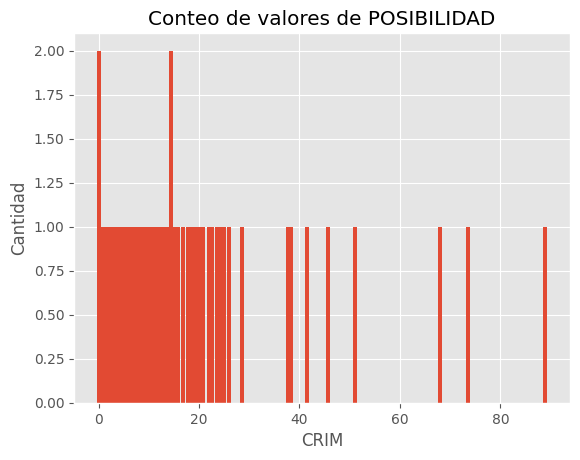

ZN


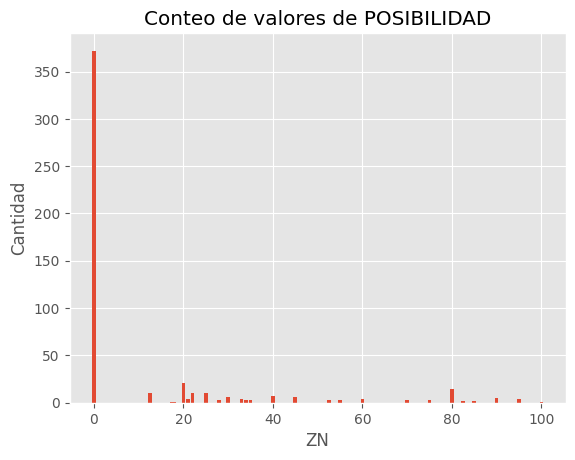

INDUS


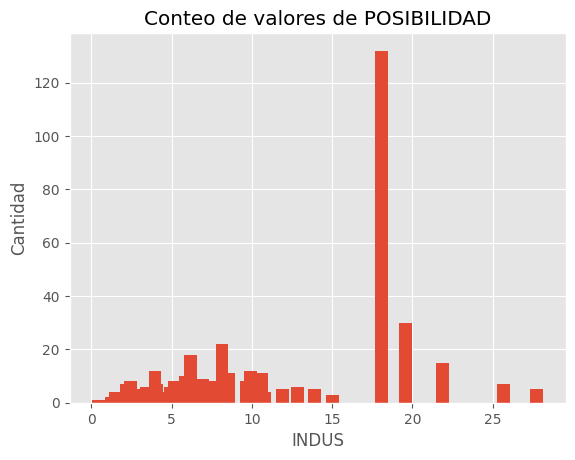

CHAS


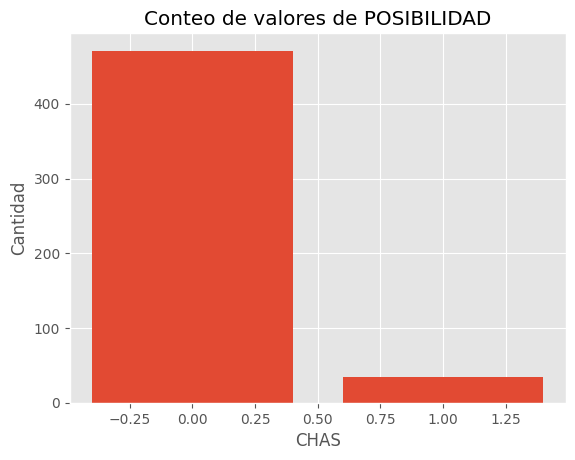

NOX


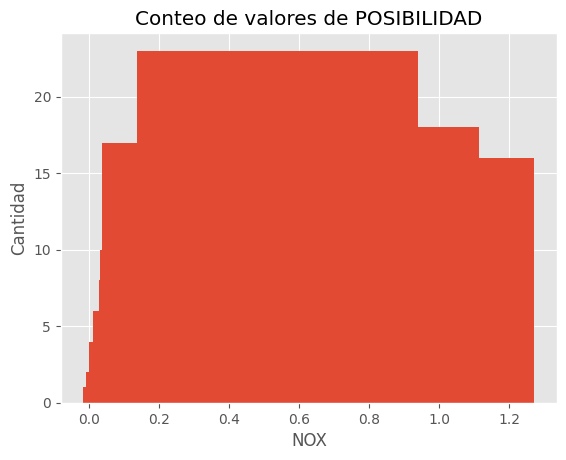

RM


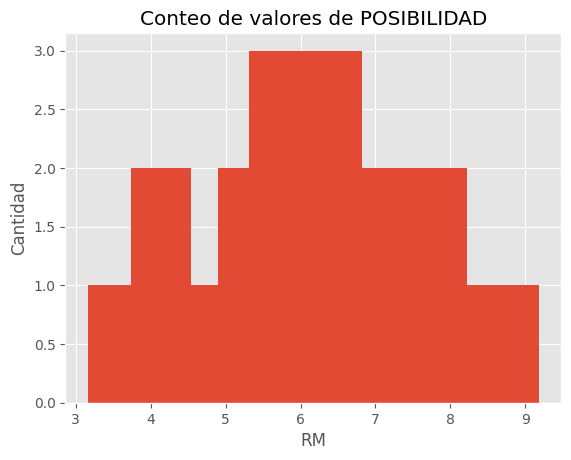

AGE


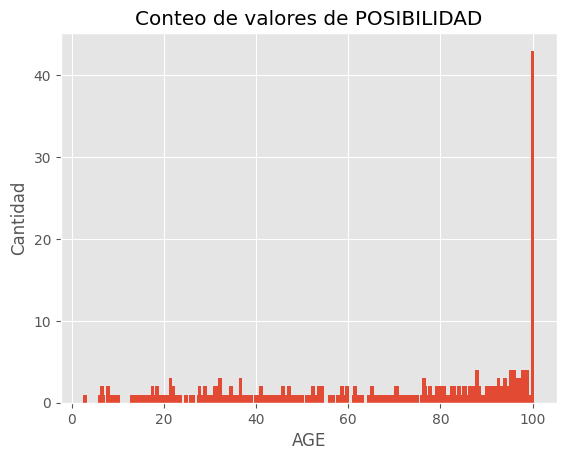

DIS


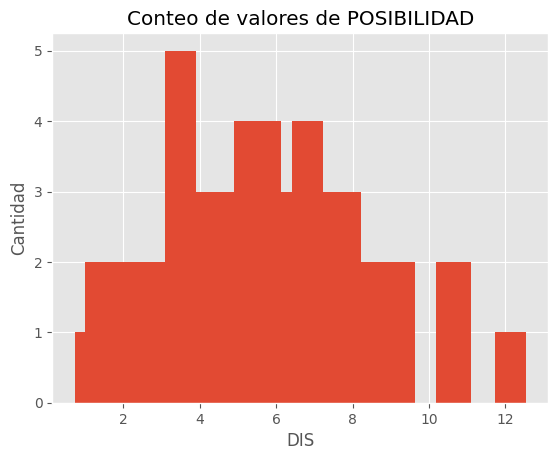

RAD


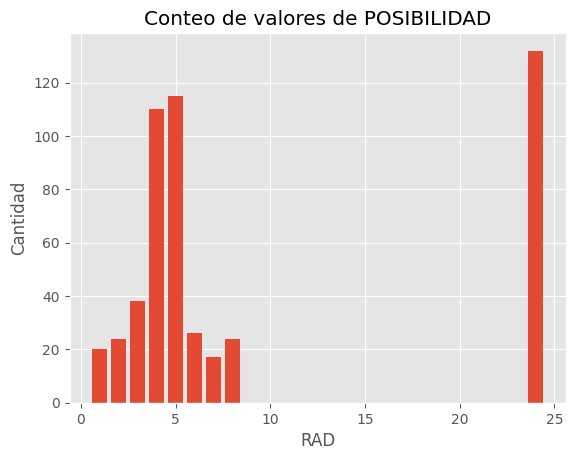

TAX


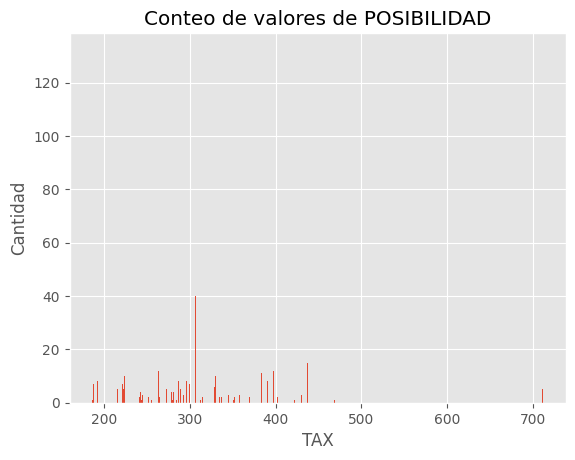

PTRATIO


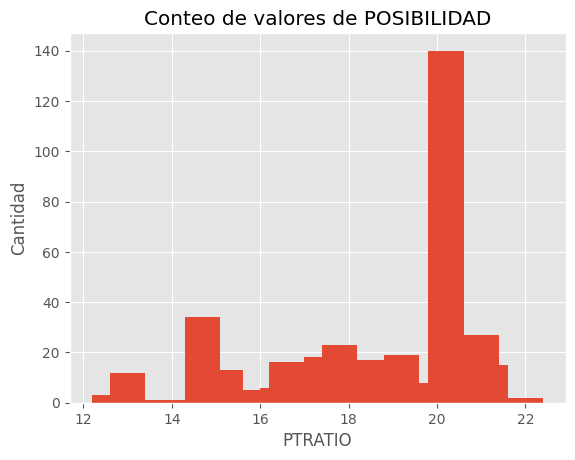

B


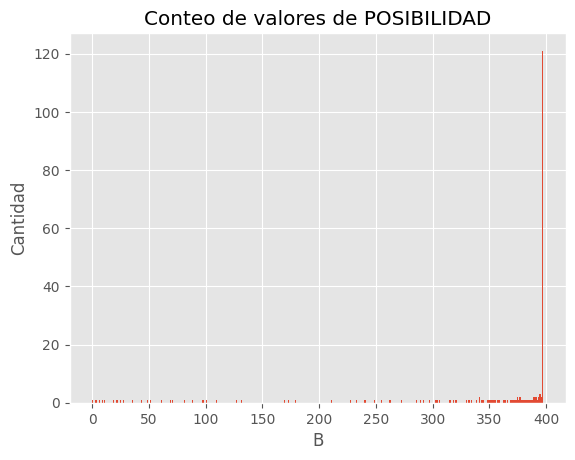

LSTAT


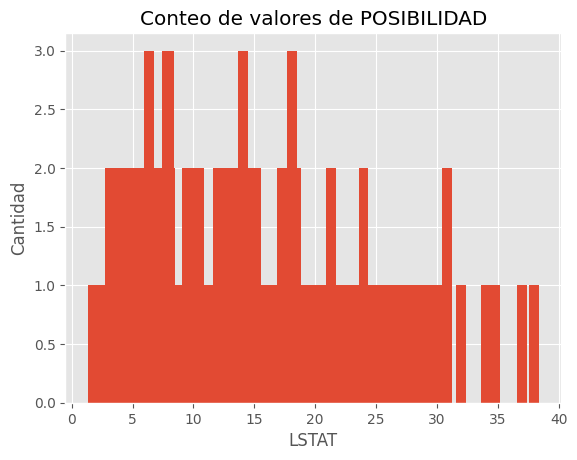

MEDV


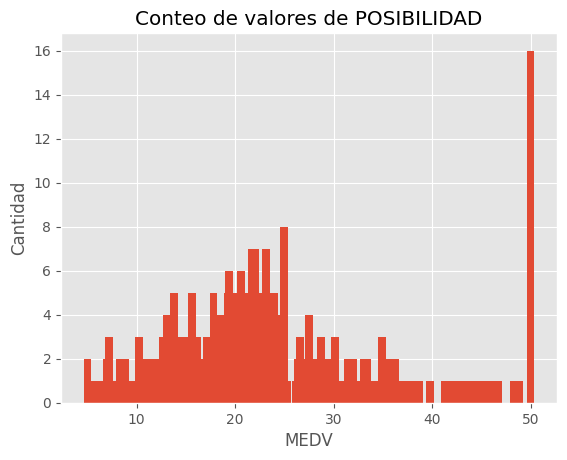

In [6]:
columnas=['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM',
       'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B',
       'LSTAT', 'MEDV']
for i in columnas:
  print(i)
  conteo_pneumonia = data[i].value_counts()
  plt.bar(conteo_pneumonia.index, conteo_pneumonia.values)
  plt.xlabel(i)
  plt.ylabel('Cantidad')
  plt.title('Conteo de valores de POSIBILIDAD')
  plt.show()

**6. Genere los gráficos de distribución de todas las variables con el siguiente código:**

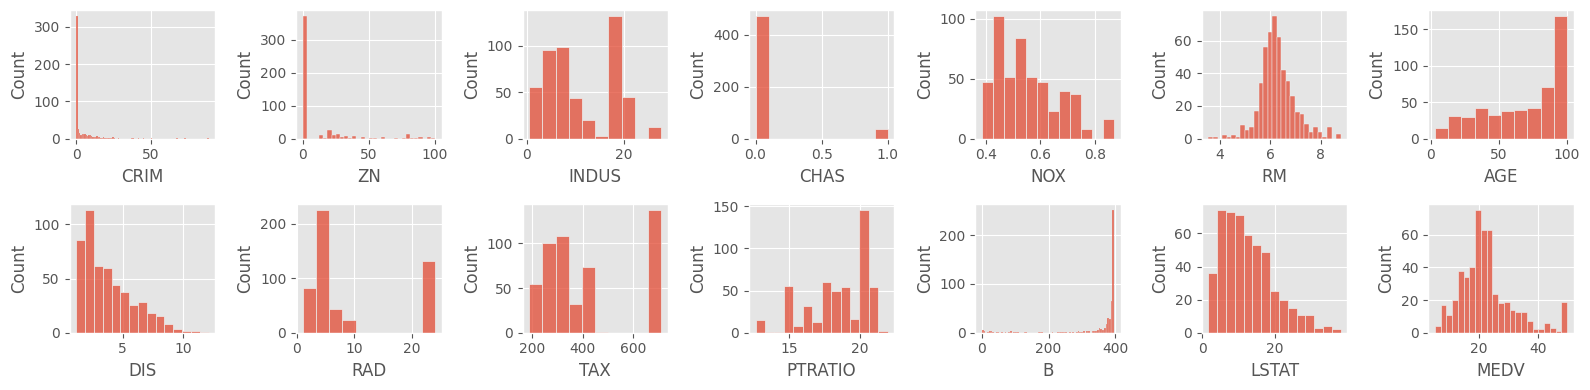

In [7]:
rows = 2
cols = 7
fig, ax = plt.subplots(nrows = rows , ncols = cols , figsize = (16,4))
col = data.columns
index = 0
for i in range(rows):
 for j in range(cols):
    sns.histplot(data[col[index]], ax = ax[i][j])
    index +=1
plt.tight_layout()

**7. Muestre el mapa de calor de la matriz de correlación y su formato tidy ignorando
la variable objetivo: MEDV.**

Text(0.5, 1.0, 'Mapa de correlación')

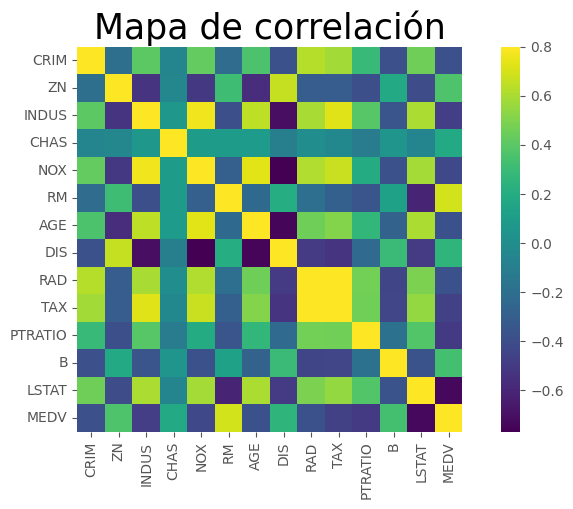

In [8]:
corrmat = data.corr()
f, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(corrmat, vmax=.8, square=True, cmap='viridis');
plt.title('Mapa de correlación',size=25)

**8. Elimine las columnas que están altamente correlacionadas (>0.7) ignorando la
variable objetivo: MEDV.**

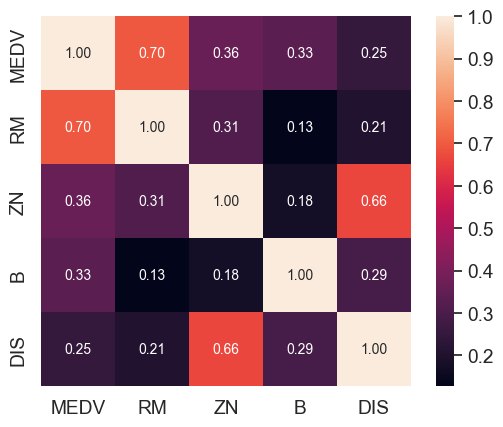

In [9]:
k=5 #numero de variables

cols = corrmat.nlargest(k, 'MEDV')['MEDV'].index # las 10 mas relacionadas con SalePrice

cm = np.corrcoef(data[cols].values.T)#Coeficiente de correlacion, el .T es que la transpone (la transpuesta)
cm

sns.set(font_scale=1.25) #Tamaño

hm = sns.heatmap(cm, cbar=True, annot=True, square=True, fmt='.2f', annot_kws={'size': 10}, yticklabels=cols.values, xticklabels=cols.values)

In [10]:
columnas_a_eliminar = ['NOX', 'AGE', 'DIS', 'TAX']
corr = data.corr()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(np.bool_))
drop = [column for column in upper.columns if any(np.abs(upper[column]) > 0.7)]
print(f"columns dropped are: {drop}")
print(f"columns dropped are: {columnas_a_eliminar}")
data = data.drop(columns=columnas_a_eliminar)

columns dropped are: ['NOX', 'AGE', 'DIS', 'TAX', 'MEDV']
columns dropped are: ['NOX', 'AGE', 'DIS', 'TAX']


In [11]:
data

,CRIM,ZN,INDUS,CHAS,RM,RAD,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,6.575,1,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,6.421,2,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,7.185,2,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,6.998,3,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,7.147,3,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,6.593,1,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,6.120,1,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,6.976,1,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,6.794,1,21.0,393.45,6.48,22.0


**9. Elimine las columnas de varianza baja (ninguna, pero realice la prueba).**

In [12]:
num_cols = data.select_dtypes('number').columns

low_var_cols = []
for col in num_cols:
    scaled = (data[col] - data[col].mean()) / data[col].std()
    variance = scaled.var().round(4)
    if variance == 0 or data[col].std() == 0:
        low_var_cols.append(col)
#     else:
#         print(col, variance)

data.drop(columns=low_var_cols, axis=1, inplace=True)
print(f"Removed Columns: {low_var_cols}")
print(data.shape, len(low_var_cols))

Removed Columns: []
(506, 10) 0


In [13]:
data

,CRIM,ZN,INDUS,CHAS,RM,RAD,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,6.575,1,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,6.421,2,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,7.185,2,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,6.998,3,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,7.147,3,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,6.593,1,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,6.120,1,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,6.976,1,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,6.794,1,21.0,393.45,6.48,22.0


**10.Realice el grafico de barras y el de bigotes de la variable objetivo.**

<Axes: ylabel='MEDV'>

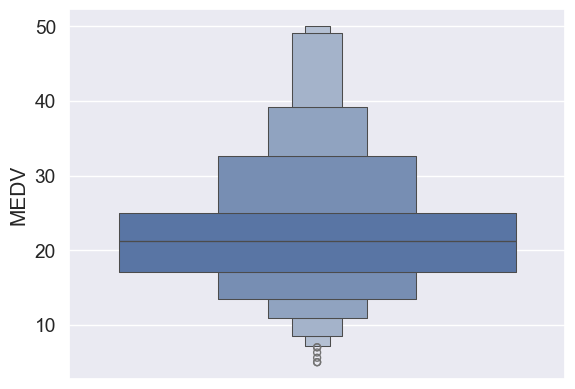

In [14]:
 sns.boxenplot(data['MEDV'])

<Axes: xlabel='MEDV', ylabel='Count'>

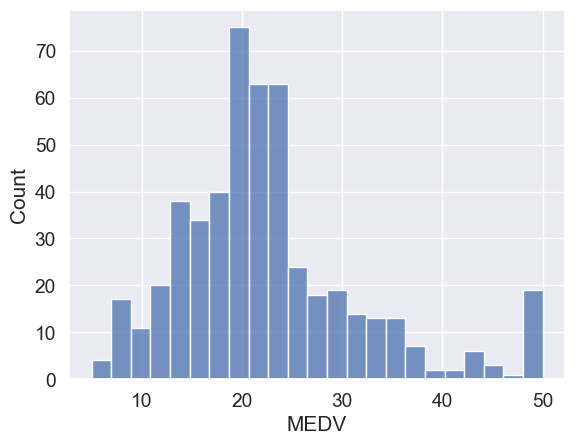

In [15]:
sns.histplot(data['MEDV'])

**11.Escale los datos con MinMaxScaler**

In [16]:
# Inicializar el MinMaxScaler
scaler = MinMaxScaler()

# Ajustar el scaler a los datos y transformarlos
data_scaled = pd.DataFrame(scaler.fit_transform(data), columns=data.columns)

print("DataFrame original:")
print(data)
print("\nDataFrame escalado:")
print(data_scaled)

DataFrame original:
        CRIM    ZN  INDUS  CHAS     RM  RAD  PTRATIO       B  LSTAT  MEDV
0    0.00632  18.0   2.31     0  6.575    1     15.3  396.90   4.98  24.0
1    0.02731   0.0   7.07     0  6.421    2     17.8  396.90   9.14  21.6
2    0.02729   0.0   7.07     0  7.185    2     17.8  392.83   4.03  34.7
3    0.03237   0.0   2.18     0  6.998    3     18.7  394.63   2.94  33.4
4    0.06905   0.0   2.18     0  7.147    3     18.7  396.90   5.33  36.2
..       ...   ...    ...   ...    ...  ...      ...     ...    ...   ...
501  0.06263   0.0  11.93     0  6.593    1     21.0  391.99   9.67  22.4
502  0.04527   0.0  11.93     0  6.120    1     21.0  396.90   9.08  20.6
503  0.06076   0.0  11.93     0  6.976    1     21.0  396.90   5.64  23.9
504  0.10959   0.0  11.93     0  6.794    1     21.0  393.45   6.48  22.0
505  0.04741   0.0  11.93     0  6.030    1     21.0  396.90   7.88  11.9

[506 rows x 10 columns]

DataFrame escalado:
         CRIM    ZN     INDUS  CHAS        RM 

**12.Separe los datos en 80% entrenamiento y 20% para pruebas.**

In [17]:
data_scaled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   RM       506 non-null    float64
 5   RAD      506 non-null    float64
 6   PTRATIO  506 non-null    float64
 7   B        506 non-null    float64
 8   LSTAT    506 non-null    float64
 9   MEDV     506 non-null    float64
dtypes: float64(10)
memory usage: 39.7 KB


In [18]:
X = data_scaled.drop(columns=['MEDV'])
# Y contendrá la columna de la variable objetivo
y = data_scaled['MEDV']

In [19]:
X

,CRIM,ZN,INDUS,CHAS,RM,RAD,PTRATIO,B,LSTAT
0,0.000000,0.18,0.067815,0.0,0.577505,0.000000,0.287234,1.000000,0.089680
1,0.000236,0.00,0.242302,0.0,0.547998,0.043478,0.553191,1.000000,0.204470
2,0.000236,0.00,0.242302,0.0,0.694386,0.043478,0.553191,0.989737,0.063466
3,0.000293,0.00,0.063050,0.0,0.658555,0.086957,0.648936,0.994276,0.033389
4,0.000705,0.00,0.063050,0.0,0.687105,0.086957,0.648936,1.000000,0.099338
...,...,...,...,...,...,...,...,...,...
501,0.000633,0.00,0.420455,0.0,0.580954,0.000000,0.893617,0.987619,0.219095
502,0.000438,0.00,0.420455,0.0,0.490324,0.000000,0.893617,1.000000,0.202815
503,0.000612,0.00,0.420455,0.0,0.654340,0.000000,0.893617,1.000000,0.107892
504,0.001161,0.00,0.420455,0.0,0.619467,0.000000,0.893617,0.991301,0.131071


In [20]:
y

0      0.422222
1      0.368889
2      0.660000
3      0.631111
4      0.693333
         ...   
501    0.386667
502    0.346667
503    0.420000
504    0.377778
505    0.153333
Name: MEDV, Length: 506, dtype: float64

In [21]:

X_train, X_test, y_train, y_test = train_test_split(
                                        X,
                                        y.values.reshape(-1,1),
                                        train_size   = 0.8,
                                        random_state = 1234,
                                        shuffle      = True
                                    )


In [22]:
# Supongamos que tienes un umbral de 0.5
umbral = 0.5
y_train = (y_train > umbral).astype(int)

**13.Haga 1 primer modelo de red neuronal con 1 sola capa y un número de neuronas
entre 100 y 150, por ejemplo:**

In [23]:
from sklearn.neural_network import MLPClassifier
nn = MLPClassifier(
 activation='relu',
 hidden_layer_sizes=(120),
 alpha=0.001,
 random_state=20,
 early_stopping=False)
nn.fit(X_train, y_train)

MLPClassifier(alpha=0.001, hidden_layer_sizes=120, random_state=20)

**14.Realice las predicciones del modelo con los datos de prueba (test) y muestre el
puntaje Rcuadrado y los errores RMSE, MAE y MSE.**

In [24]:
# Realizar predicciones en el conjunto de prueba
y_pred = nn.predict(X_test)

# Calcular el puntaje R cuadrado (R²)
r2 = r2_score(y_test, y_pred)

# Calcular errores
rmse = mean_squared_error(y_test, y_pred, squared=False)  # RMSE
mae = mean_absolute_error(y_test, y_pred)  # MAE
mse = mean_squared_error(y_test, y_pred)  # MSE

# Mostrar los resultados
print("Puntaje R²:", r2)
print("RMSE:", rmse)
print("MAE:", mae)
print("MSE:", mse)

Puntaje R²: -1.4733307412224765
RMSE: 0.3540834175301602
MAE: 0.3147712418300654
MSE: 0.12537506656983777


**15.Realice una búsqueda de la mejor configuración del modelo con GridSearchCV**

In [25]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
import numpy as np

# Crear el modelo
nn = MLPClassifier(random_state=20, early_stopping=False)

# Definir los parámetros a ajustar
parametros = {
    'hidden_layer_sizes': [(100,), (120,), (150,), (180,), (200,), (30, 30), (60, 60), (80, 80), (100, 100)],
    'alpha': np.logspace(-3, 3, 6),
    'learning_rate_init': [0.00001, 0.0001, 0.001, 0.01],
    'activation': ['tanh', 'relu', 'logistic']
}

# Crear el objeto GridSearchCV
grid_search = GridSearchCV(nn, parametros, cv=5, scoring='r2', verbose=1, n_jobs=-1)

# Ajustar el modelo a los datos de entrenamiento
grid_search.fit(X_train, y_train)

# Imprimir los mejores parámetros y el mejor puntaje
print("Mejores parámetros encontrados:")
print(grid_search.best_params_)
print("Mejor puntaje R² encontrado:", grid_search.best_score_)

# Realizar predicciones en el conjunto de prueba con el mejor modelo encontrado
mejor_modelo = grid_search.best_estimator_
y_pred = mejor_modelo.predict(X_test)

# Calcular y mostrar los resultados de evaluación
r2 = r2_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("\nPuntaje R² en conjunto de prueba:", r2)
print("RMSE en conjunto de prueba:", rmse)
print("MAE en conjunto de prueba:", mae)
print("MSE en conjunto de prueba:", mse)

Fitting 5 folds for each of 648 candidates, totalling 3240 fits
Mejores parámetros encontrados:
{'activation': 'relu', 'alpha': 0.001, 'hidden_layer_sizes': (180,), 'learning_rate_init': 0.01}
Mejor puntaje R² encontrado: 0.6158823529411764

Puntaje R² en conjunto de prueba: -1.3280610432743059
RMSE en conjunto de prueba: 0.3435276293796175
MAE en conjunto de prueba: 0.3074074074074074
MSE en conjunto de prueba: 0.11801123214717985


**16.Muestre los mejores 15 o 20 resultados ordenándolos por 'mean_test_score'.**

In [26]:
# Obtener los resultados de la búsqueda en un DataFrame
resultados_df = pd.DataFrame(grid_search.cv_results_)

# Seleccionar las columnas relevantes
columnas_seleccionadas = ['params', 'mean_test_score', 'std_test_score']
mejores_resultados = resultados_df[columnas_seleccionadas]

# Ordenar los resultados por 'mean_test_score' de manera descendente
mejores_resultados = mejores_resultados.sort_values(by='mean_test_score', ascending=False)

# Mostrar los mejores 15 resultados
mejores_15_resultados = mejores_resultados.head(15)

# Mostrar los resultados
print("Los mejores 15 resultados ordenados por 'mean_test_score':")
print(mejores_15_resultados)

Los mejores 15 resultados ordenados por 'mean_test_score':
                                                params  mean_test_score  \
231  {'activation': 'relu', 'alpha': 0.001, 'hidden...         0.615882   
283  {'activation': 'relu', 'alpha': 0.015848931924...         0.583945   
287  {'activation': 'relu', 'alpha': 0.015848931924...         0.570478   
271  {'activation': 'relu', 'alpha': 0.015848931924...         0.569839   
235  {'activation': 'relu', 'alpha': 0.001, 'hidden...         0.569791   
267  {'activation': 'relu', 'alpha': 0.015848931924...         0.569791   
243  {'activation': 'relu', 'alpha': 0.001, 'hidden...         0.569104   
299  {'activation': 'relu', 'alpha': 0.251188643150...         0.569104   
275  {'activation': 'relu', 'alpha': 0.015848931924...         0.569104   
279  {'activation': 'relu', 'alpha': 0.015848931924...         0.568272   
107  {'activation': 'tanh', 'alpha': 0.251188643150...         0.554949   
223  {'activation': 'relu', 'alpha': 0.00

**17.Con el mejor modelo obtenido (modelo_final = grid.best_estimator_) realice las
predicciones del conjunto de prueba.**

In [27]:
# Obtener el mejor modelo encontrado por GridSearchCV
mejor_modelo = grid_search.best_estimator_

# Realizar predicciones en el conjunto de prueba
y_pred = mejor_modelo.predict(X_test)

**18.Obtenga el puntaje Rcuadrado y los errores RMSE, MAE y MSE.**

In [28]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Calcular el puntaje R cuadrado (R²)
r2 = r2_score(y_test, y_pred)

# Calcular errores
rmse = mean_squared_error(y_test, y_pred, squared=False)  # RMSE
mae = mean_absolute_error(y_test, y_pred)  # MAE
mse = mean_squared_error(y_test, y_pred)  # MSE

# Mostrar los resultados
print("Puntaje R² en conjunto de prueba:", r2)
print("RMSE en conjunto de prueba:", rmse)
print("MAE en conjunto de prueba:", mae)
print("MSE en conjunto de prueba:", mse)


Puntaje R² en conjunto de prueba: -1.3280610432743059
RMSE en conjunto de prueba: 0.3435276293796175
MAE en conjunto de prueba: 0.3074074074074074
MSE en conjunto de prueba: 0.11801123214717985


**19.Muestre las graficas que sirven para el diagnóstico de residuos.**

In [ ]:
predicciones=y_pred

In [ ]:
residuos_train = predicciones - y_test

In [ ]:
residuos_test = predicciones - y_test

In [ ]:
y_test.size

In [ ]:
y_pred.size

In [ ]:
import statsmodels.api as sm
# Gráficos
# ==============================================================================
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(8, 14))

axes[0, 0].scatter(y_test, predicciones, edgecolors=(0, 0, 0), alpha = 0.4)
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
                'k--', color = 'black', lw=2)
axes[0, 0].set_title('Valor predicho vs valor real', fontsize = 10, fontweight = "bold")
axes[0, 0].set_xlabel('Real')
axes[0, 0].set_ylabel('Predicción')
axes[0, 0].tick_params(labelsize = 7)

axes[0, 1].scatter(list(range(len(y_test))), residuos_train,
                   edgecolors=(0, 0, 0), alpha = 0.4)
axes[0, 1].axhline(y = 0, linestyle = '--', color = 'black', lw=2)
axes[0, 1].set_title('Residuos del modelo', fontsize = 10, fontweight = "bold")
axes[0, 1].set_xlabel('id')
axes[0, 1].set_ylabel('Residuo')
axes[0, 1].tick_params(labelsize = 7)

sns.histplot(
    data    = residuos_test,
    stat    = "density",
    kde     = True,
    line_kws= {'linewidth': 1},
    color   = "firebrick",
    alpha   = 0.3,
    ax      = axes[1, 0]
)

axes[1, 0].set_title('Distribución residuos del modelo', fontsize = 10,
                     fontweight = "bold")
axes[1, 0].set_xlabel("Residuo")
axes[1, 0].tick_params(labelsize = 7)


sm.qqplot(
    residuos_test,
    fit   = True,
    line  = 'q',
    ax    = axes[1, 1], 
    color = 'firebrick',
    alpha = 0.4,
    lw    = 2
)
axes[1, 1].set_title('Q-Q residuos del modelo', fontsize = 10, fontweight = "bold")
axes[1, 1].tick_params(labelsize = 7)

axes[2, 0].scatter(predicciones, residuos_test,
                   edgecolors=(0, 0, 0), alpha = 0.4)
axes[2, 0].axhline(y = 0, linestyle = '--', color = 'black', lw=2)
axes[2, 0].set_title('Residuos del modelo vs predicción', fontsize = 10, fontweight = "bold")
axes[2, 0].set_xlabel('Predicción')
axes[2, 0].set_ylabel('Residuo')
axes[2, 0].tick_params(labelsize = 7)

# Se eliminan los axes vacíos
fig.delaxes(axes[2,1])

fig.tight_layout()
plt.subplots_adjust(top=0.9)
fig.suptitle('Diagnóstico residuos', fontsize = 12, fontweight = "bold");
plt.show()

**20.Muestre los pesos y el bias del modelo.**

In [29]:
# Obtener los coeficientes (pesos) y sesgos (biases) del mejor modelo
coeficientes = mejor_modelo.coefs_
sesgos = mejor_modelo.intercepts_

# Mostrar los pesos de cada capa
for i, coef in enumerate(coeficientes):
    print(f"Pesos de la capa {i + 1}: {coef}")

# Mostrar los sesgos de cada capa
for i, sesgo in enumerate(sesgos):
    print(f"Sesgos de la capa {i + 1}: {sesgo}")


Pesos de la capa 1: [[ 3.41740486e-07  3.54406641e-02  7.17818810e-02 ...  7.76032351e-03
  -1.57830069e-01  3.39473968e-02]
 [-3.01220375e-07 -3.54470105e-02 -1.85532204e-01 ...  2.15794716e-01
   2.22781554e-01 -9.73210533e-02]
 [-3.97294936e-06 -1.16586708e-01 -2.70951307e-01 ... -1.83145859e-01
  -3.20861317e-02  2.27256568e-01]
 ...
 [-1.14074171e-06  1.11643899e-03 -1.52413069e-01 ... -6.59918357e-02
   8.15024817e-02  2.88944349e-01]
 [ 2.38794399e-07 -7.95410120e-02  1.08807404e-01 ...  2.67780725e-02
  -3.13071418e-02  2.33181911e-02]
 [-2.94890622e-07  6.35983580e-02 -3.00698568e-01 ... -4.49757857e-02
   7.34330789e-01  5.86639100e-01]]
Pesos de la capa 2: [[-3.08035274e-06]
 [ 7.29913245e-02]
 [ 1.94304857e-01]
 [-1.15035632e-01]
 [ 2.57419578e-01]
 [-1.63663156e-01]
 [-1.58817647e-01]
 [-3.70149642e-01]
 [-1.07269852e-01]
 [-6.36123254e-02]
 [-1.99598726e-03]
 [-1.40147682e-01]
 [ 2.86254300e-02]
 [ 3.40126816e-01]
 [-5.65394932e-06]
 [-4.23642608e-01]
 [-2.65827012e-01]
 

**21.Usando Keras genere una red neuronal con 2 capas ocultas que tengan entre 20
y 100 neuronas y la capa de salida que tenga 1 sola neurona.
Puede elegir como función de activación: relu, tanh, softmax o sigmoid.
Por ejemplo:**

In [30]:
import numpy as np
from keras.models import Sequential
from keras.layers import Dense
model = Sequential([
 Dense(60, activation='tanh', input_shape=[9]),
 Dense(40, activation='relu'),
 Dense(1)
 ])
model.compile (loss='mean_squared_error', optimizer='adam',
metrics=['mae', 'mse'])
model.fit(X_train, y_train, epochs=300)
# evaluamos el modelo
scores = model.evaluate(X_test, y_test)




Epoch 1/300


13/13 [==============================] - 3s 3ms/step - loss: 0.1566 - mae: 0.2815 - mse: 0.1566
Epoch 2/300
13/13 [==============================] - 0s 2ms/step - loss: 0.1177 - mae: 0.2731 - mse: 0.1177
Epoch 3/300
13/13 [==============================] - 0s 2ms/step - loss: 0.0914 - mae: 0.2222 - mse: 0.0914
Epoch 4/300
13/13 [==============================] - 0s 2ms/step - loss: 0.0851 - mae: 0.2114 - mse: 0.0851
Epoch 5/300
13/13 [==============================] - 0s 2ms/step - loss: 0.0792 - mae: 0.2091 - mse: 0.0792
Epoch 6/300
13/13 [==============================] - 0s 2ms/step - loss: 0.0741 - mae: 0.1856 - mse: 0.0741
Epoch 7/300
13/13 [==============================] - 0s 2ms/step - loss: 0.0707 - mae: 0.1796 - mse: 0.0707
Epoch 8/300
13/13 [==============================] - 0s 2ms/step - loss: 0.0683 - mae: 0.1767 - mse: 0.0683
Epoch 9/300
13/13 [==============================] - 0s 2ms/step - loss: 0.0646 - mae: 0.1669 - mse: 0.0646
Epoch 10/300
13/13 [===

**22.Obtenga las predicciones del modelo con los datos de test y calcule el puntaje
Rcuadrado y los errores MAE, MSE y RMSE.**

In [31]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Obtener predicciones en el conjunto de prueba
y_pred = mejor_modelo.predict(X_test)

# Calcular el puntaje R cuadrado (R²)
r2 = r2_score(y_test, y_pred)

# Calcular errores
mae = mean_absolute_error(y_test, y_pred)  # MAE
mse = mean_squared_error(y_test, y_pred)  # MSE
rmse = mean_squared_error(y_test, y_pred, squared=False)  # RMSE

# Mostrar los resultados
print("Puntaje R² en conjunto de prueba:", r2)
print("MAE en conjunto de prueba:", mae)
print("MSE en conjunto de prueba:", mse)
print("RMSE en conjunto de prueba:", rmse)


Puntaje R² en conjunto de prueba: -1.3280610432743059
MAE en conjunto de prueba: 0.3074074074074074
MSE en conjunto de prueba: 0.11801123214717985
RMSE en conjunto de prueba: 0.3435276293796175


**23.Muestre las graficas que sirven para el diagnóstico de residuos.**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

# Calcular los residuos
residuos = y_test - y_pred

# Gráfico de residuos vs. valores predichos
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuos, alpha=0.5)
plt.title('Gráfico de Residuos vs. Valores Predichos')
plt.xlabel('Valores Predichos')
plt.ylabel('Residuos')
plt.axhline(y=0, color='r', linestyle='--')
plt.show()

# Histograma de residuos
plt.figure(figsize=(10, 6))
sns.histplot(residuos, bins=30, kde=True)
plt.title('Histograma de Residuos')
plt.xlabel('Residuos')
plt.ylabel('Frecuencia')
plt.show()

# Gráfico Q-Q de residuos
plt.figure(figsize=(10, 6))
stats.probplot(residuos, dist="norm", plot=plt)
plt.title('Gráfico Q-Q de Residuos')
plt.xlabel('Cuantiles teóricos')
plt.ylabel('Cuantiles de residuos')
plt.show()


**24.Realice el diagrama del mejor modelo de red neuronal con viznet.**

In [32]:
pip install viznet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 23.3.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Press `c` to save figure to "_feed_forward.png", `Ctrl+d` to break >>
> c:\users\roberto\appdata\local\programs\python\python311\lib\site-packages\viznet\context.py(61)__exit__()
     59                   self.filename)
     60             pdb.set_trace()
---> 61             plt.savefig(self.filename, dpi=300, transparent=True)
     62         else:
     63             pdb.set_trace()



ipdb>  -c


*** NameError: name 'c' is not defined


ipdb>  c-


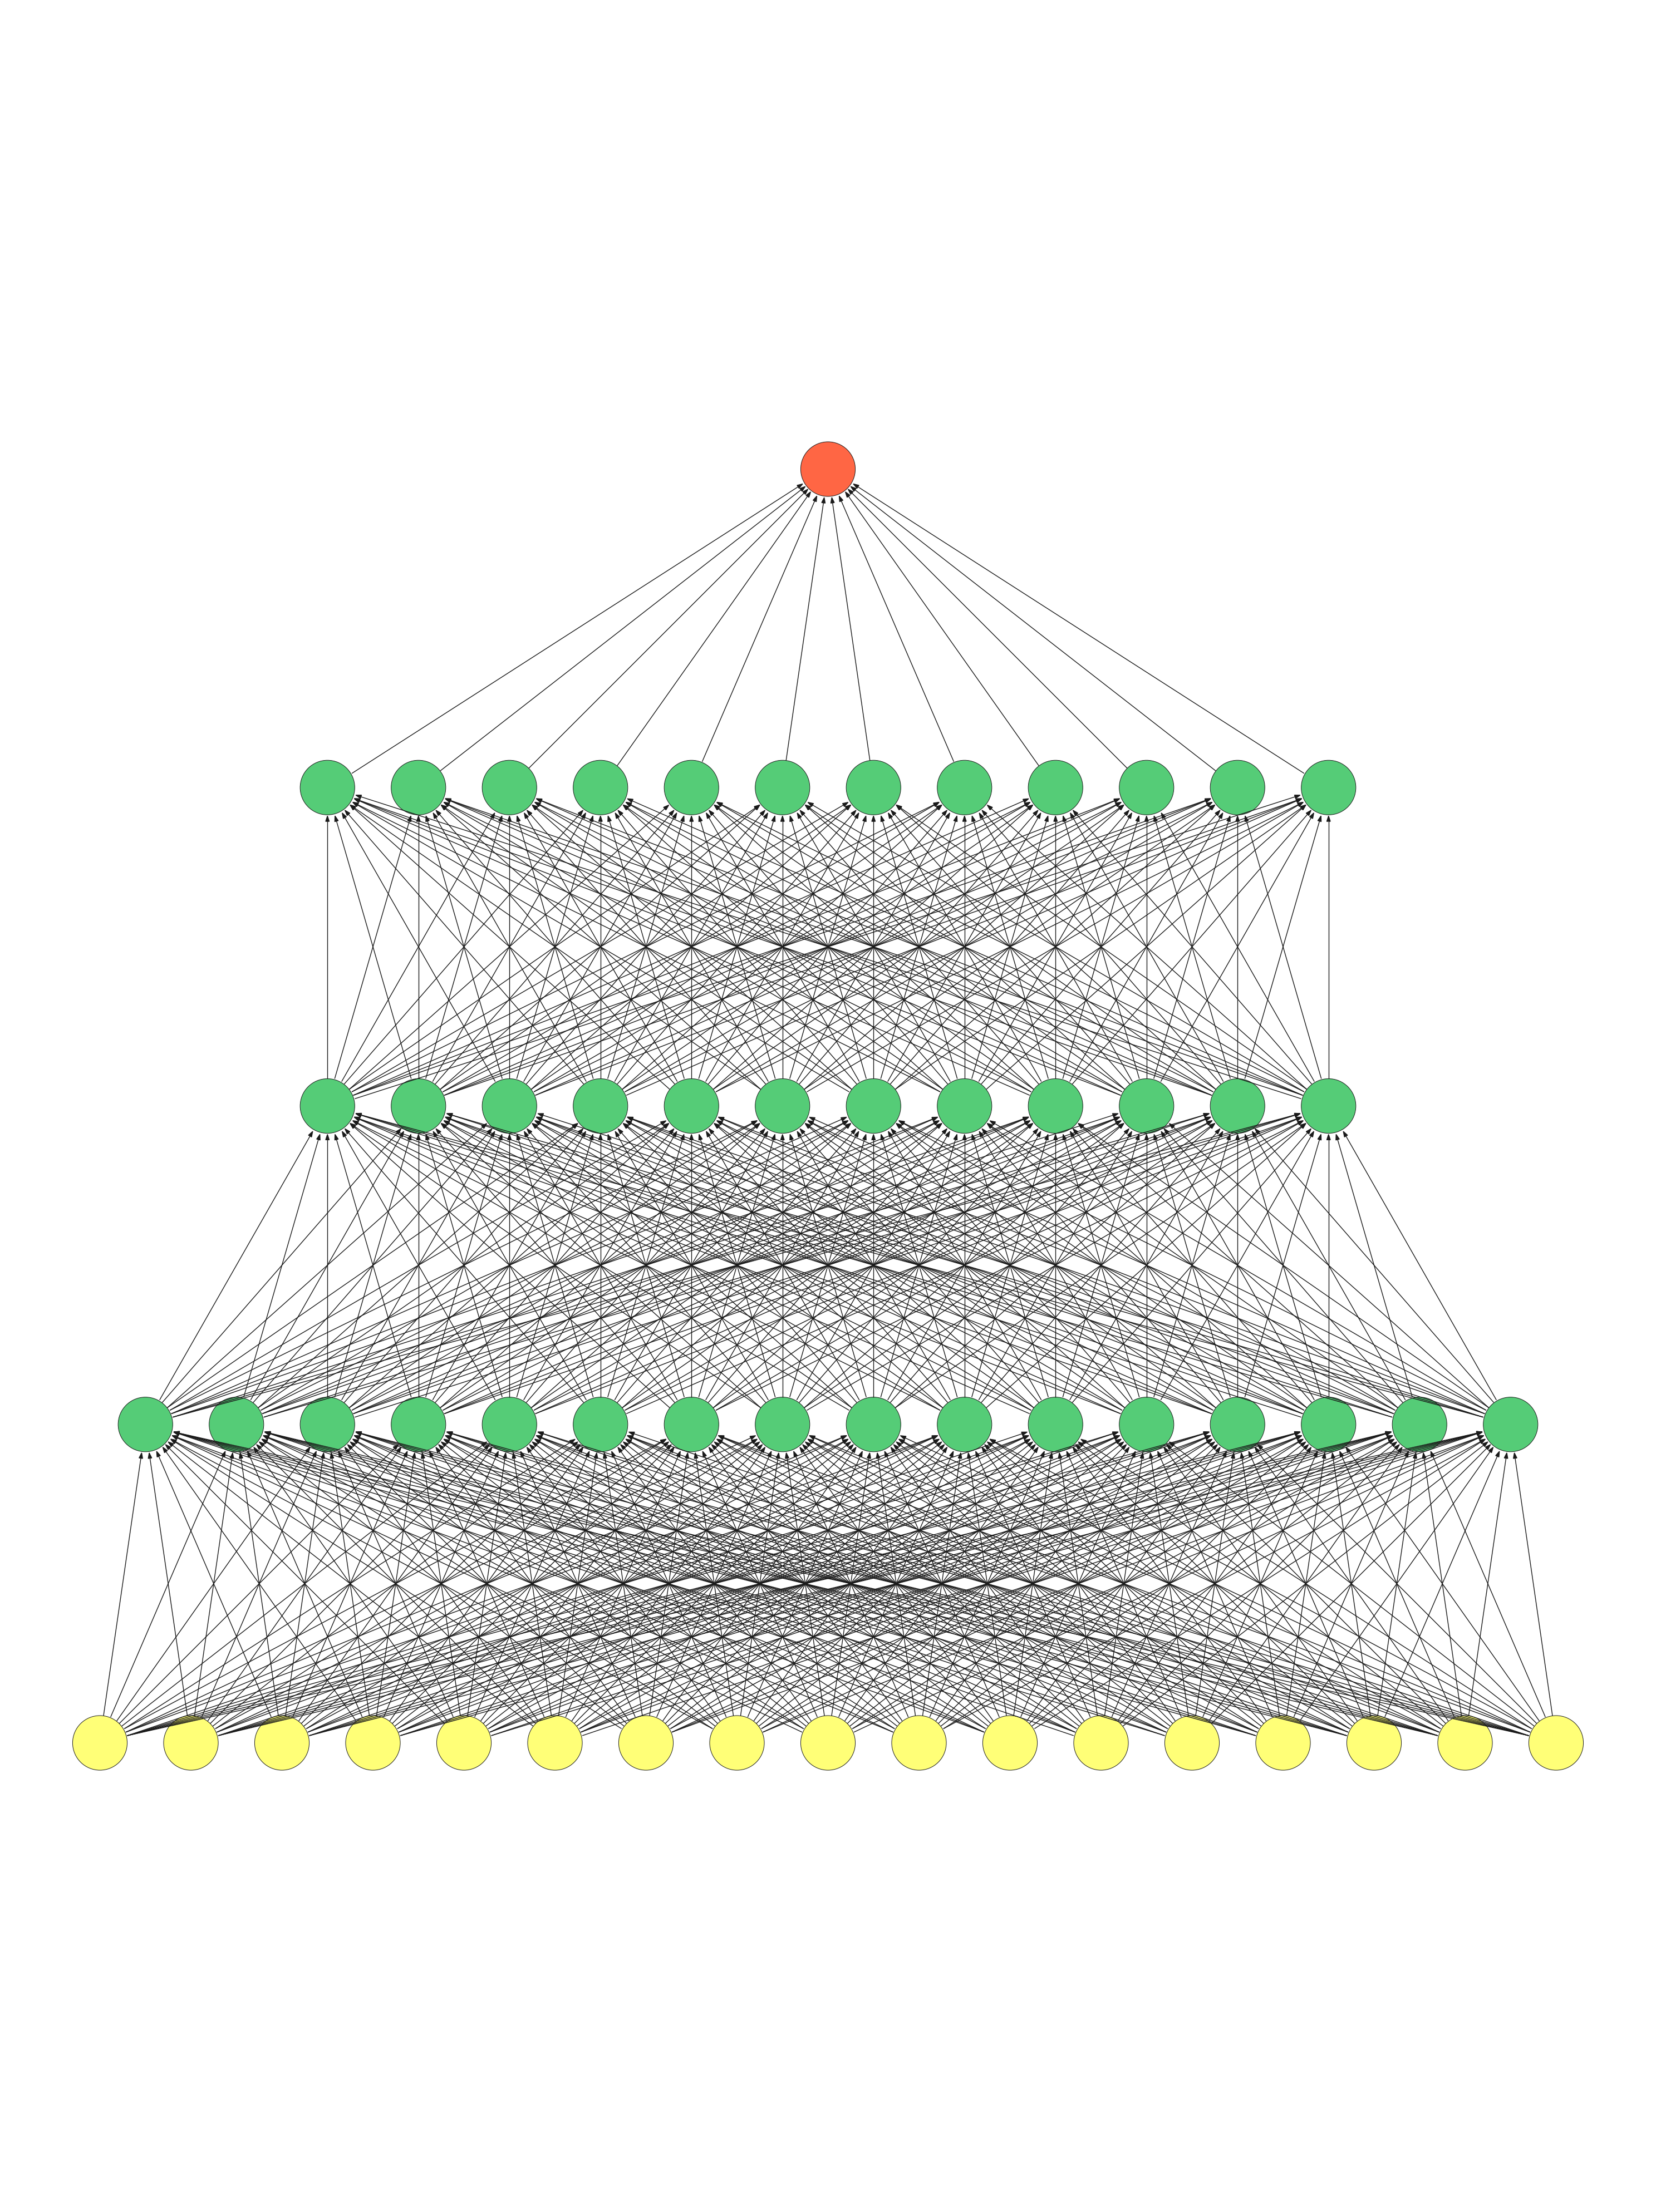

In [33]:
import numpy as np
from viznet import connecta2a, node_sequence, NodeBrush, EdgeBrush, DynamicShow


def draw_feed_forward(ax, num_node_list):
    '''
    draw a feed forward neural network.

    Args:
        num_node_list (list<int>): number of nodes in each layer.
    '''
    num_hidden_layer = len(num_node_list) - 2
    token_list = ['\sigma^z'] + \
        ['y^{(%s)}' % (i + 1) for i in range(num_hidden_layer)] + ['\psi']
    kind_list = ['nn.input'] + ['nn.hidden'] * num_hidden_layer + ['nn.output']
    radius_list = [0.3] + [0.2] * num_hidden_layer + [0.3]
    y_list = 3.5 * np.arange(len(num_node_list))

    seq_list = []
    for n, kind, radius, y in zip(num_node_list, kind_list, radius_list, y_list):
        b = NodeBrush(kind, ax)
        seq_list.append(node_sequence(b, n, center=(0, y)))

    eb = EdgeBrush('-->', ax)
    for st, et in zip(seq_list[:-1], seq_list[1:]):
        connecta2a(st, et, eb)


def real_bp():
    with DynamicShow((30, 40), '_feed_forward.png') as d:
        draw_feed_forward(d.ax, num_node_list=[17,16,12,12, 1])


if __name__ == '__main__':
    real_bp()



<h2>Mejores resultados de cada red neuronal</h2>
<table border="1">
    <tr>
        <th>Modelo</th>
        <th>Configuración</th>
        <th>R^2</th>
        <th>RMSE</th>
        <th>MAE</th>
    </tr>
    <tr>
        <td>Mejor red neuronal<br>scikit-learn</td>
        <td>Función activación: , learning rate: <br>
            Capa oculta 1: # neuronas</td>
        <td>-1.3280610432743059</td>
        <td>0.3435276293796175</td>
        <td>0.3074074074074074</td>
    </tr>
    <tr>
        <td>Mejor red neuronal<br>Keras</td>
        <td>Capa oculta 1: # neuronas, función <br>
            Capa oculta 2: #neuronas, función <br>
            Capa salida: 1 neurona, función</td>
        <td>-1.3280610432743059</td>
        <td>0.3074074074074074</td>
        <td>0.11801123214717985</td>
    </tr>
</table>
